## Шаг 2. Статистическая нормализация доменных шкал (StandardScaler)

Вход: `df_domains.csv` из шага 01. Выход: z-score матрица, статистики scaler, `domain_scaler.joblib`.

In [11]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from artifact_loader import domain_data_path

In [12]:
df_domains = pd.read_csv(domain_data_path())

print(f"rows: {len(df_domains)}, domains: {df_domains.shape[1]}")
print(f"domain NaN rate: {df_domains.isna().mean().mean():.2%}")

rows: 775, domains: 13
domain NaN rate: 0.00%


Доменные шкалы приводятся к нулевому среднему и единичной дисперсии — нужно для distance-based методов (KMeans, GMM, PCA).

- `df_domains` — исходные значения 0–4 (остаются в `artifacts/csv/clean/`)
- `df_domains_scaled` — z-score после `StandardScaler`
- редкие оставшиеся `NaN` в доменах заполняются медианой **только** перед scaling

rows: 775, domains: 13
domain NaN imputed for scaling: 0


,raw_mean,raw_std,scaled_mean,scaled_std
trainability,1.472,0.397,-0.0,1.001
stranger_directed_aggression,0.436,0.635,0.0,1.001
owner_directed_aggression,0.186,0.397,0.0,1.001
dog_directed_aggression,1.317,0.995,-0.0,1.001
stranger_directed_fear,0.631,0.895,-0.0,1.001
nonsocial_fear,1.034,0.723,0.0,1.001
dog_directed_fear,0.811,0.994,0.0,1.001
touch_sensitivity,0.633,0.761,-0.0,1.001
separation_related,0.614,0.602,-0.0,1.001
excitability,2.049,0.761,-0.0,1.001


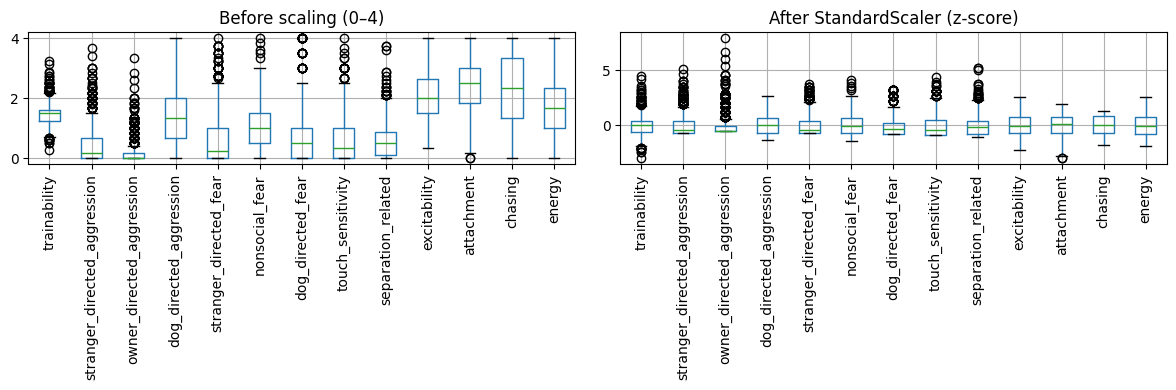

In [13]:
domain_nan_before = df_domains.isna().sum().sum()
df_domains_imputed = df_domains.fillna(df_domains.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_domains_imputed)

df_domains_scaled = pd.DataFrame(
    X_scaled,
    index=df_domains.index,
    columns=df_domains.columns,
)

scaler_stats = pd.DataFrame(
    {
        "raw_mean": scaler.mean_,
        "raw_std": scaler.scale_,
        "scaled_mean": df_domains_scaled.mean(),
        "scaled_std": df_domains_scaled.std(),
    },
    index=df_domains.columns,
).round(3)

print(f"rows: {len(df_domains_scaled)}, domains: {df_domains_scaled.shape[1]}")
print(f"domain NaN imputed for scaling: {domain_nan_before}")
display(scaler_stats)

assert np.allclose(df_domains_scaled.mean(), 0, atol=1e-10)
assert np.allclose(df_domains_scaled.std(ddof=0), 1, atol=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_domains.boxplot(ax=axes[0], rot=90)
axes[0].set_title("Before scaling (0–4)")
df_domains_scaled.boxplot(ax=axes[1], rot=90)
axes[1].set_title("After StandardScaler (z-score)")
plt.tight_layout()
plt.show()

In [14]:
for key, df in {
    "df_scaled": df_domains_scaled,
    "scaler_stats": scaler_stats,
}.items():
    out = PATHS[key]
    out.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out, index=False)
    print(f"Saved: {out} — {df.shape[0]} rows, {df.shape[1]} columns")

scaler_out = PATHS["scaler"]
scaler_out.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, scaler_out)
print(f"Saved: {scaler_out}")

Saved: ../artifacts/csv/scaled/df_domains_scaled.csv — 775 rows, 13 columns
Saved: ../artifacts/csv/scaled/scaler_stats.csv — 13 rows, 4 columns
Saved: ../artifacts/models/domain_scaler.joblib
